In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/disney-stock-data/walt disney.csv


In [4]:
!pip install pyecharts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.1/161.1 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import altair as alt

from pyecharts.charts import Kline
from pyecharts import options as opts

from IPython.display import HTML


In [6]:
import plotly.io as pio

pio.renderers.default = 'iframe'

In [7]:
HTML("""
<style>

.disney-header{
background:linear-gradient(135deg,#0f172a,#1e293b);
padding:40px;
border-radius:12px;
color:white;
font-family:Arial;
}

.disney-title{
font-size:42px;
font-weight:bold;
}

.disney-sub{
font-size:18px;
color:#94a3b8;
}

</style>

<div class='disney-header'>
<div class='disney-title'>Disney Research Lab</div>
<div class= disney-sub'>Advanced Technical Indicators & Market Structure Analysis</div>
</div>

""")

In [8]:
df = pd.read_csv('/kaggle/input/disney-stock-data/walt disney.csv')
data = df.copy()
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)

df.head()

,Open,High,Low,Close,Volume
Date,,,,,
1962-01-02,0.057055,0.058970,0.057055,0.057055,841958
1962-01-03,0.057055,0.058012,0.057055,0.057821,801865
1962-01-04,0.057821,0.058012,0.057438,0.057821,962238
1962-01-05,0.057821,0.058204,0.057630,0.058012,962238
1962-01-08,0.058012,0.058778,0.056672,0.057821,1282984


In [9]:
df["returns"] = df["Close"].pct_change()

df["volatility"] = df["returns"].rolling(30).std()

df["SMA50"] = df["Close"].rolling(50).mean()

df["SMA200"] = df["Close"].rolling(200).mean()

df["RSI"] = 100 - (100 / (1 + df["returns"].rolling(14).mean() /
                         df["returns"].rolling(14).std()))

df["momentum"] = df["Close"].pct_change(90)

df["drawdown"] = df["Close"] / df["Close"].cummax() - 1

df = df.dropna()

In [10]:
df_1 = df.iloc[-4999:]

In [11]:
chart = alt.Chart(df_1.reset_index()).mark_line().encode(
    x="Date:T",
    y="Close:Q",
    tooltip=["Date","Close"]
).properties(
    width=800,
    height=400,
    title="Disney Price Evolution"
)

chart.interactive()

alt.Chart(...)

In [12]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
    x=df.index,
    open=df["Open"],
    high=df["High"],
    low=df["Low"],
    close=df["Close"],
    name="DIS Price"
))

fig.update_layout(
title="Disney Market Structure",
template="plotly_dark",
height=600
)

fig.show()

In [13]:
fig = px.line(
df,
y=["Close","SMA50","SMA200"],
title="Trend Regime Analysis",
template="plotly_dark"
)

fig.show()

In [14]:
fig = px.area(
df,
y="volatility",
title="Market Volatility Regime",
template="plotly_dark"
)

fig.show()

In [15]:
fig = px.bar(
df,
y="Volume",
title="Liquidity & Volume Flow",
template="plotly_dark"
)

fig.show()

In [16]:
fig = px.line(
df,
y="RSI",
title="Relative Strength Index",
template="plotly_dark"
)

fig.add_hline(y=70)
fig.add_hline(y=30)

fig.show()

In [17]:
fig = px.area(
df,
y="drawdown",
title="Maximum Drawdown Cycles",
template="plotly_dark"
)

fig.show()

In [18]:
df["alpha"] = df["momentum"] - df["volatility"]

In [19]:
fig = px.scatter(
df,
x="alpha",
y="returns",
color="volatility",
title="Alpha Signal vs Returns",
template="plotly_dark"
)

fig.show()

In [20]:
df["year"] = df.index.year

fig = px.line(
df,
x=df.index,
y="Close",
animation_frame="year",
title="Disney Stock Evolution by Year",
template="plotly_dark"
)

fig.show()

In [21]:
HTML(f"""

<div style='display:flex'>

<div style='padding:20px;background:#111827;margin:10px;border-radius:10px;color:white'>
<h3>Total Years</h3>
<h1>{len(df)//252}</h1>
</div>

<div style='padding:20px;background:#111827;margin:10px;border-radius:10px;color:white'>
<h3>Avg Volatility</h3>
<h1>{round(df.volatility.mean(),4)}</h1>
</div>

<div style='padding:20px;background:#111827;margin:10px;border-radius:10px;color:white'>
<h3>Max Drawdown</h3>
<h1>{round(df.drawdown.min(),2)}</h1>
</div>

</div>

""")

In [22]:
fig = go.Figure()
 
# Add traces for Open, High, Low, and Close prices
fig.add_trace(go.Scatter(x=data.index, y=data['Open'], mode='lines', name='Open', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=data.index, y=data['High'], mode='lines', name='High', line=dict(color='green')))
fig.add_trace(go.Scatter(x=data.index, y=data['Low'], mode='lines', name='Low', line=dict(color='red')))
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Close', line=dict(color='purple')))

# Add candlestick chart
fig.add_trace(go.Candlestick(x=data.index,
                             open=data['Open'],
                             high=data['High'],
                             low=data['Low'],
                             close=data['Close'],
                             name='Candlestick',
                             increasing_line_color='green',
                             decreasing_line_color='red'))

# Customize layout
fig.update_layout(title='Disney Stock Price Analysis',
                  xaxis_title='Date',
                  yaxis_title='Price',
                  template='plotly_dark')

# Show the interactive plot
fig.show()


In [23]:
fig = go.Figure()

# Add volume trace
fig.add_trace(go.Bar(x=data.index, y=data['Volume'], name='Volume', marker_color='blue', opacity=0.3))

# Calculate moving average
data['Moving_Avg'] = data['Close'].rolling(window=30).mean()
fig.add_trace(go.Scatter(x=data.index, y=data['Moving_Avg'], mode='lines', name='30-Day Moving Average', line=dict(color='orange')))

# Customize layout
fig.update_layout(title='Disney Stock Volume and Moving Average',
                  xaxis_title='Date',
                  yaxis_title='Volume',
                  template='plotly_dark')

# Show the interactive plot
fig.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



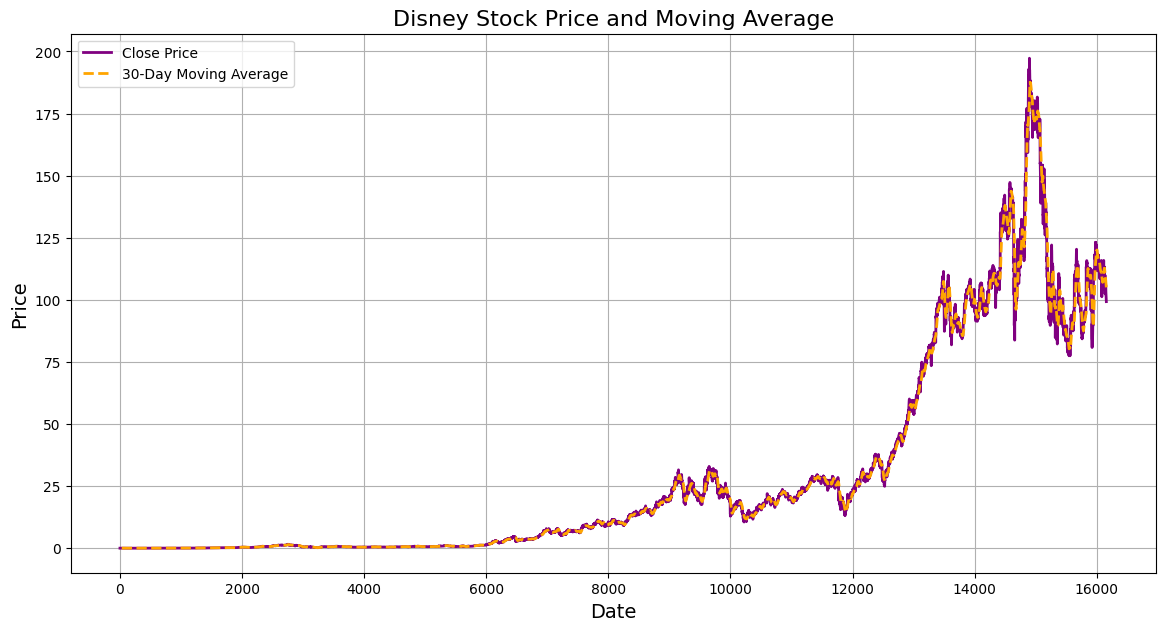

In [24]:
plt.figure(figsize=(14, 7))

# Plotting the closing price
sns.lineplot(data=data, x=data.index, y='Close', label='Close Price', color='purple', lw=2)

# Add moving average
data['Moving_Avg'] = data['Close'].rolling(window=30).mean()
sns.lineplot(data=data, x=data.index, y='Moving_Avg', label='30-Day Moving Average', color='orange', linestyle='--', lw=2)

# Add titles and labels
plt.title('Disney Stock Price and Moving Average', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
